In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler()
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [31]:
df = sns.load_dataset('geyser')
df.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


In [32]:
df.shape

(272, 3)

In [33]:
df.isnull().sum()

duration    0
waiting     0
kind        0
dtype: int64

In [34]:
x = df.drop(columns=['kind'])
y = df['kind']

In [35]:
x_scaled = scaled.fit_transform(x)
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)
x_scaled_df.head()

,duration,waiting
0,0.098499,0.597123
1,-1.481459,-1.245181
2,-0.135861,0.228663
3,-1.057503,-0.655644
4,0.917443,1.039277


In [36]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=2)
label = kmean.fit_predict(x_scaled_df)
x_scaled_df['cluster'] = label

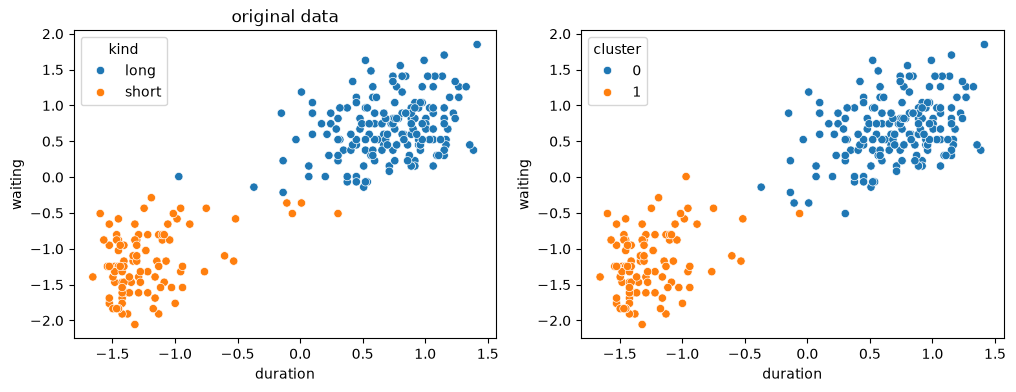

In [37]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.scatterplot(x = 'duration',y= 'waiting',data= x_scaled_df,hue=y)
plt.title('original data')
plt.subplot(1,2,2)
sns.scatterplot(x = 'duration',y= 'waiting',data= x_scaled_df,hue='cluster')
plt.show()

In [38]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
x_scaled_df_pca = pd.DataFrame(x_pca,columns=['pca_1','pca_2'])

In [39]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=2)
pca_label = kmean.fit_predict(x_pca)
x_scaled_df_pca['pca_cluster'] = pca_label

In [40]:
x_scaled_df_pca.head()

,pca_1,pca_2,pca_cluster
0,0.491879,0.352581,0
1,-1.928025,0.167073,1
2,0.065620,0.257757,0
3,-1.211378,0.284158,1
4,1.383610,0.086149,0


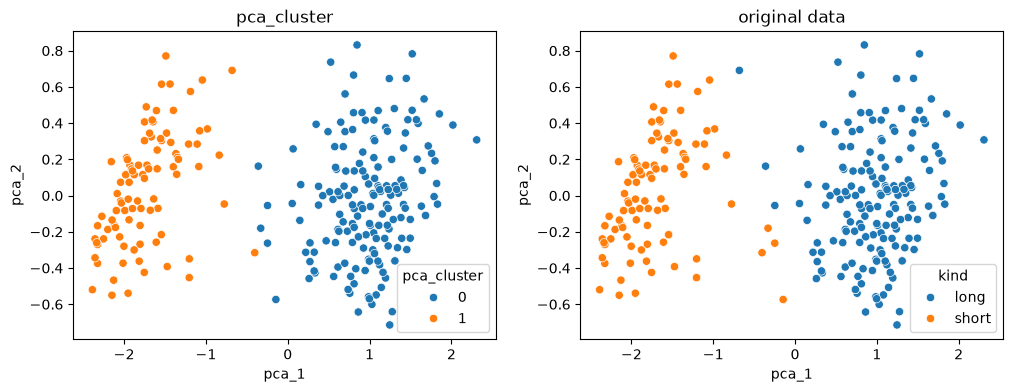

In [41]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.scatterplot(x= 'pca_1',y= 'pca_2',data= x_scaled_df_pca,hue= 'pca_cluster')
plt.title('pca_cluster')
plt.subplot(1,2,2)
sns.scatterplot(x= 'pca_1',y= 'pca_2',data= x_scaled_df_pca,hue= y)
plt.title('original data')
plt.show()


In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Features me se cluster column exclude rakhein
X_input = x_scaled_df[['duration', 'waiting']]

# Binary classification me n_components sirf 1 ho sakta hai
lda = LinearDiscriminantAnalysis(n_components=1)
x_lda = lda.fit_transform(X_input, y)

lda_reduction = pd.DataFrame(x_lda, columns=['lda1'])
lda_reduction.head()

,lda1
0,-0.882649
1,4.363361
2,0.005168
3,2.846023
4,-3.011089


In [45]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=2)
lda_label = kmean.fit_predict(lda_reduction)
lda_reduction['lda_cluster'] = lda_label
lda_reduction.head()

,lda1,lda_cluster
0,-0.882649,0
1,4.363361,1
2,0.005168,0
3,2.846023,1
4,-3.011089,0


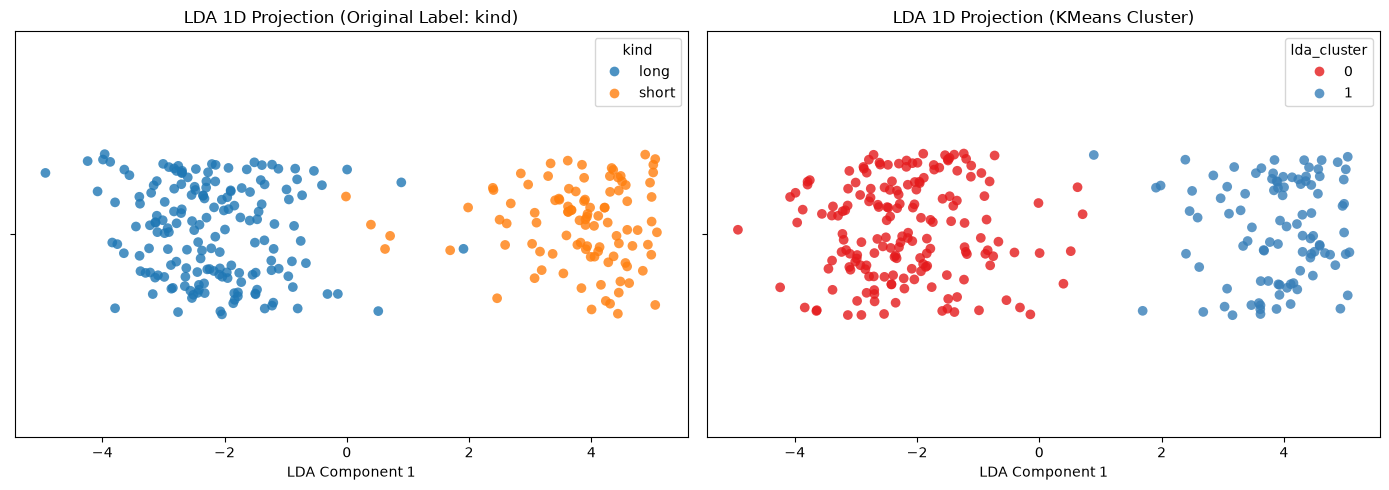

In [46]:
plt.figure(figsize=(14, 5))

# 1. LDA vs Original Label (y)
plt.subplot(1, 2, 1)
sns.stripplot(x='lda1', data=lda_reduction, hue=y, jitter=0.2, alpha=0.8, size=7)
plt.title('LDA 1D Projection (Original Label: kind)')
plt.xlabel('LDA Component 1')

# 2. LDA vs KMeans Cluster
plt.subplot(1, 2, 2)
sns.stripplot(x='lda1', data=lda_reduction, hue='lda_cluster', palette='Set1', jitter=0.2, alpha=0.8, size=7)
plt.title('LDA 1D Projection (KMeans Cluster)')
plt.xlabel('LDA Component 1')

plt.tight_layout()
plt.show()

In [47]:
from sklearn.manifold import TSNE

# t-SNE fit karein (scaled features par)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
x_tsne = tsne.fit_transform(x_scaled)

# DataFrame banayein
x_scaled_df_tsne = pd.DataFrame(x_tsne, columns=['tsne_1', 'tsne_2'])

# KMeans clustering on t-SNE components
kmean = KMeans(n_clusters=2, random_state=42)
tsne_label = kmean.fit_predict(x_tsne)
x_scaled_df_tsne['tsne_cluster'] = tsne_label

x_scaled_df_tsne.head()

,tsne_1,tsne_2,tsne_cluster
0,6.632601,-6.579088,0
1,-33.744087,4.404747,1
2,0.389298,-2.896293,0
3,-25.046148,1.537263,1
4,18.899630,-1.162927,0


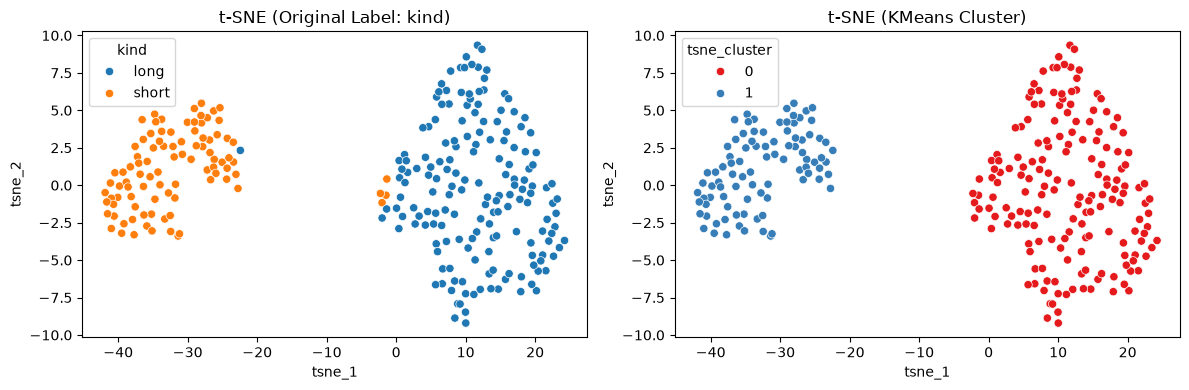

In [48]:
plt.figure(figsize=(12, 4))

# 1. t-SNE vs Original Label (y)
plt.subplot(1, 2, 1)
sns.scatterplot(x='tsne_1', y='tsne_2', data=x_scaled_df_tsne, hue=y)
plt.title('t-SNE (Original Label: kind)')

# 2. t-SNE vs KMeans Cluster
plt.subplot(1, 2, 2)
sns.scatterplot(x='tsne_1', y='tsne_2', data=x_scaled_df_tsne, hue='tsne_cluster', palette='Set1')
plt.title('t-SNE (KMeans Cluster)')

plt.tight_layout()
plt.show()

In [50]:
import umap

# UMAP model fit karein
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
x_umap = reducer.fit_transform(x_scaled)

# DataFrame banayein
x_scaled_df_umap = pd.DataFrame(x_umap, columns=['umap_1', 'umap_2'])

# KMeans Clustering on UMAP components
kmean = KMeans(n_clusters=2, random_state=42)
umap_label = kmean.fit_predict(x_umap)
x_scaled_df_umap['umap_cluster'] = umap_label

x_scaled_df_umap.head()

C:\Users\dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,umap_1,umap_2,umap_cluster
0,-2.400475,2.831283,0
1,9.627214,9.817531,1
2,-0.958176,3.973743,0
3,8.943562,6.678463,1
4,-6.379034,3.066827,0


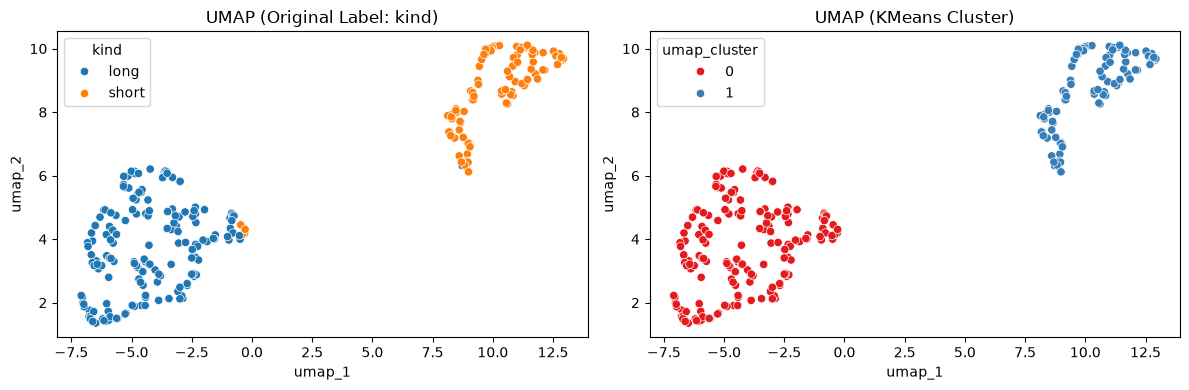

In [51]:
plt.figure(figsize=(12, 4))

# 1. UMAP vs Original Label (y)
plt.subplot(1, 2, 1)
sns.scatterplot(x='umap_1', y='umap_2', data=x_scaled_df_umap, hue=y)
plt.title('UMAP (Original Label: kind)')

# 2. UMAP vs KMeans Cluster
plt.subplot(1, 2, 2)
sns.scatterplot(x='umap_1', y='umap_2', data=x_scaled_df_umap, hue='umap_cluster', palette='Set1')
plt.title('UMAP (KMeans Cluster)')

plt.tight_layout()
plt.show()

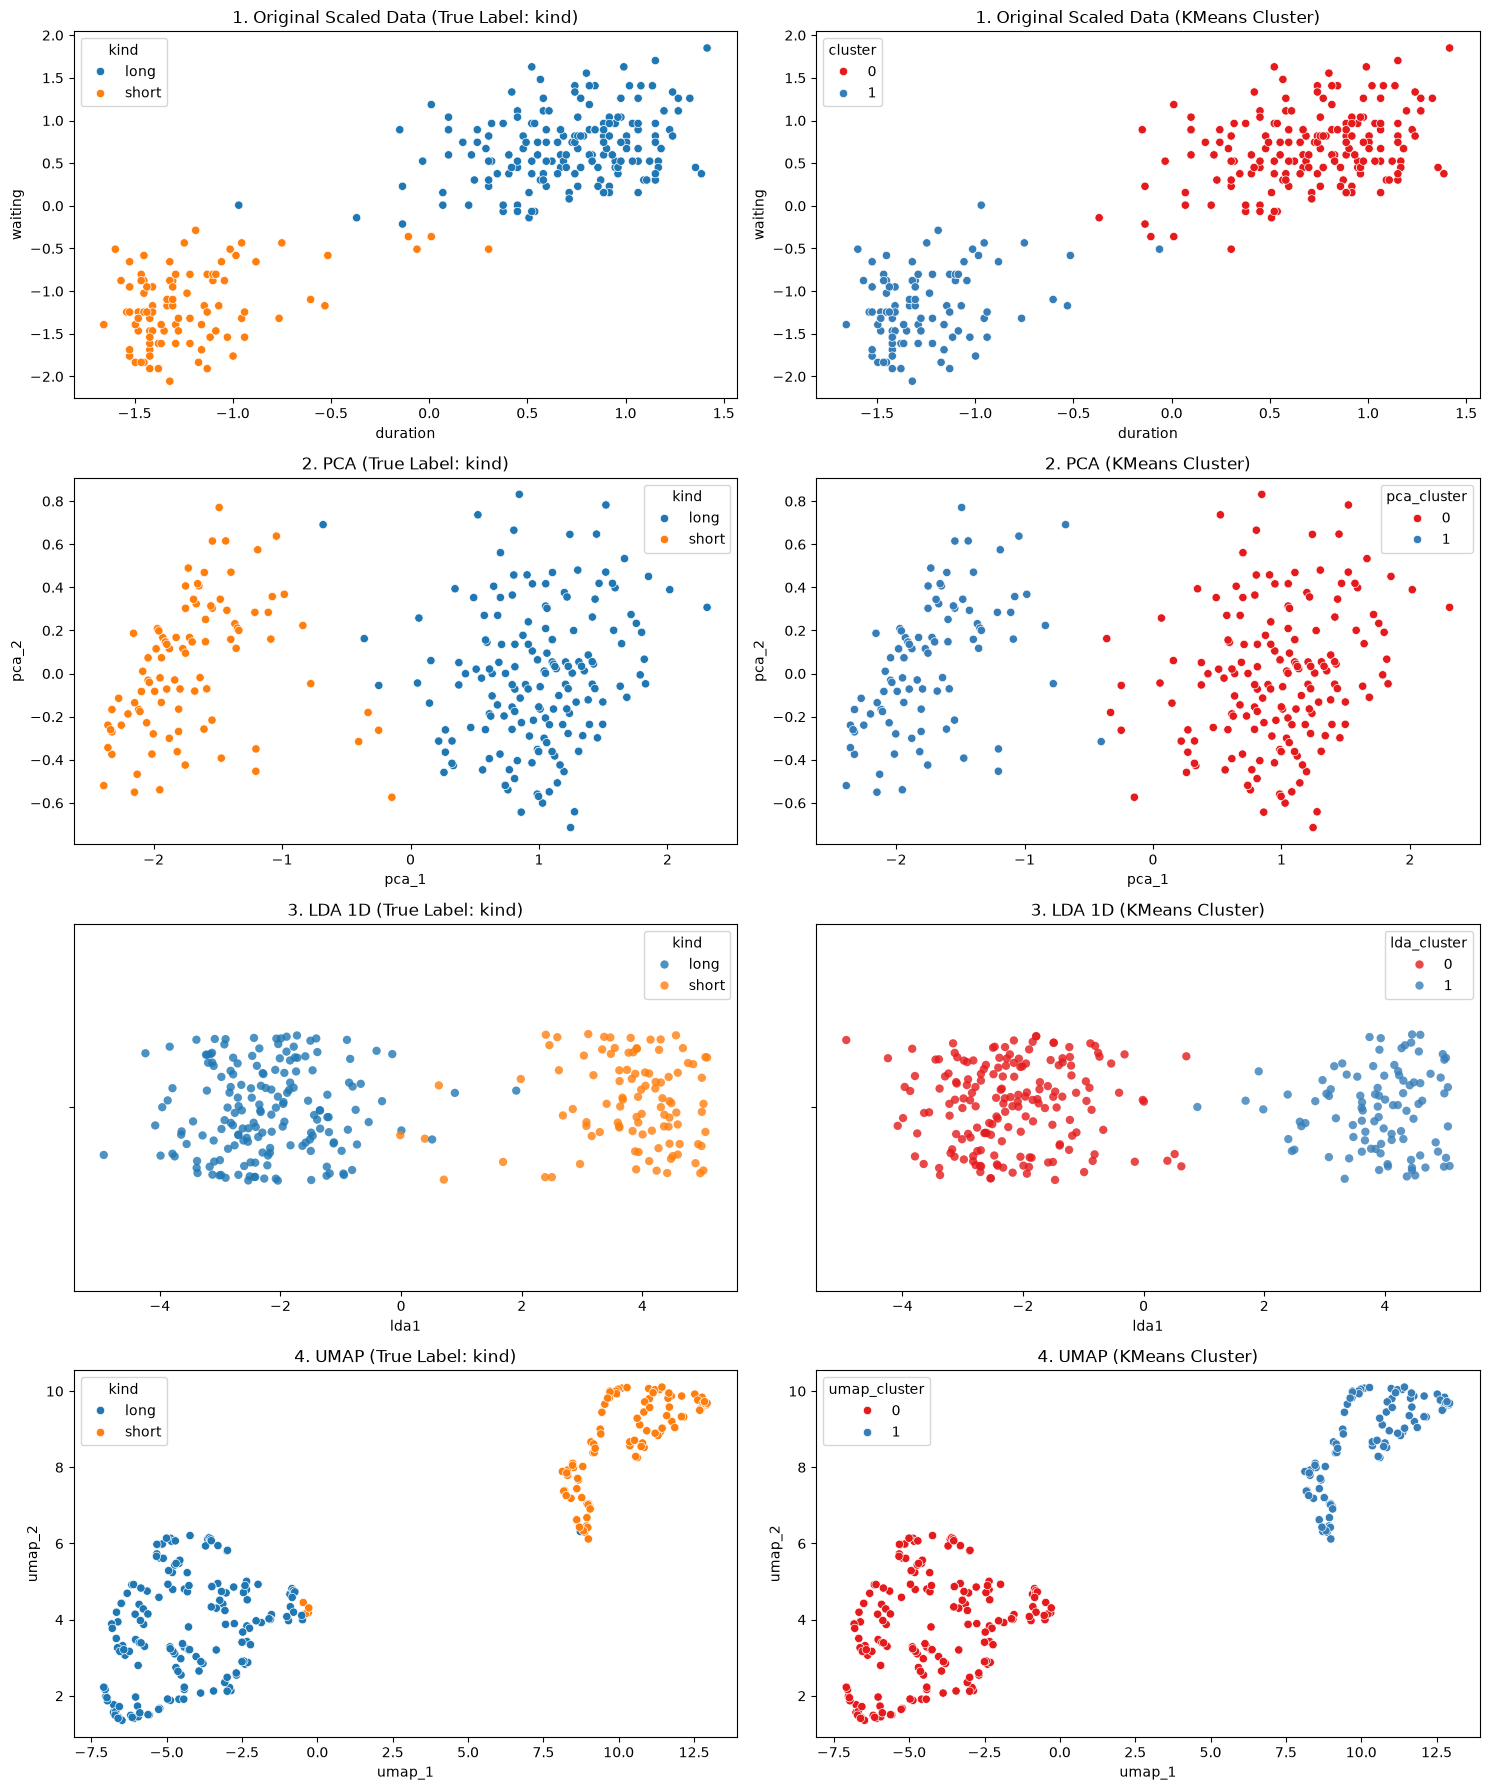

In [53]:
# Master Comparison Grid: All Techniques Side-by-Side
fig, axes = plt.subplots(4, 2, figsize=(15, 18))

# 1. Original Scaled Data
sns.scatterplot(x='duration', y='waiting', data=x_scaled_df, hue=y, ax=axes[0, 0])
axes[0, 0].set_title('1. Original Scaled Data (True Label: kind)')

sns.scatterplot(x='duration', y='waiting', data=x_scaled_df, hue='cluster', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('1. Original Scaled Data (KMeans Cluster)')

# 2. PCA
sns.scatterplot(x='pca_1', y='pca_2', data=x_scaled_df_pca, hue=y, ax=axes[1, 0])
axes[1, 0].set_title('2. PCA (True Label: kind)')

sns.scatterplot(x='pca_1', y='pca_2', data=x_scaled_df_pca, hue='pca_cluster', palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title('2. PCA (KMeans Cluster)')

# 3. LDA (1D Projection using Stripplot)
sns.stripplot(x='lda1', data=lda_reduction, hue=y, jitter=0.2, alpha=0.8, size=6, ax=axes[2, 0])
axes[2, 0].set_title('3. LDA 1D (True Label: kind)')

sns.stripplot(x='lda1', data=lda_reduction, hue='lda_cluster', palette='Set1', jitter=0.2, alpha=0.8, size=6, ax=axes[2, 1])
axes[2, 1].set_title('3. LDA 1D (KMeans Cluster)')

# 4. UMAP
sns.scatterplot(x='umap_1', y='umap_2', data=x_scaled_df_umap, hue=y, ax=axes[3, 0])
axes[3, 0].set_title('4. UMAP (True Label: kind)')

sns.scatterplot(x='umap_1', y='umap_2', data=x_scaled_df_umap, hue='umap_cluster', palette='Set1', ax=axes[3, 1])
axes[3, 1].set_title('4. UMAP (KMeans Cluster)')

plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import silhouette_score

metrics = {
    'Method': ['Original Scaled', 'PCA', 'LDA (1D)', 't-SNE', 'UMAP'],
    'Silhouette Score': [
        silhouette_score(x_scaled, x_scaled_df['cluster']),
        silhouette_score(x_pca, x_scaled_df_pca['pca_cluster']),
        silhouette_score(lda_reduction[['lda1']], lda_reduction['lda_cluster']),
        silhouette_score(x_tsne, x_scaled_df_tsne['tsne_cluster']),
        silhouette_score(x_umap, x_scaled_df_umap['umap_cluster'])
    ]
}

pd.DataFrame(metrics).sort_values(by='Silhouette Score', ascending=False).reset_index(drop=True)

,Method,Silhouette Score
0,UMAP,0.820039
1,LDA (1D),0.816226
2,t-SNE,0.791858
3,PCA,0.745177
4,Original Scaled,0.745177


Key Presentation Points (Viva / Interview ke liye):
PCA (Linear, Unsupervised): Maximum variance capture karta hai, global geometry preserve rehti hai.

LDA (Linear, Supervised): Labels (kind) ka use karke classes ke beech ka distance maximize karta hai.

t-SNE (Non-linear, Unsupervised): Local clusters bohot clear dikhata hai par global distance distort karta hai.

UMAP (Non-linear, Unsupervised): t-SNE se fast hai aur local ke saath-saath global structure ko bhi preserve karta hai.

In [55]:
import joblib

# Saare fitted objects save karein
joblib.dump(scaled, 'scaler.pkl')
joblib.dump(pca, 'pca_model.pkl')
joblib.dump(lda, 'lda_model.pkl')
joblib.dump(reducer, 'umap_model.pkl')

print("✅ Sabhi models successfully save ho gaye!")

✅ Sabhi models successfully save ho gaye!


In [ ]:
"""git init
git add app.py requirements.txt scaler.pkl pca_model.pkl lda_model.pkl umap_model.pkl
git commit -m "Deploy Geyser ML App"
git push -u origin main"""
#streamlit run app.py
#!streamlit run app.py

In [56]:
!jupyter nbconvert --to script day26.ipynb

[NbConvertApp] Converting notebook day26.ipynb to script
[NbConvertApp] Writing 9386 bytes to day26.py
